<a href="https://colab.research.google.com/github/HoangAncient/MagicPost/blob/main/Lab_3_2_CDR_Fraud_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3.2 – Phát hiện cuộc gọi gian lận CDR Fraud trong viễn thông

Bài lab này xây dựng pipeline phân loại cuộc gọi/giao dịch CDR là `Genuine` hay `Fraudulent` từ dữ liệu Kaggle thật.

## Bài toán

Input là đặc trưng của bản ghi CDR: thời điểm gọi, thời lượng, loại cuộc gọi, vị trí/country nguồn và đích.

Output là `transaction_status`: `Fraudulent` hoặc `Genuine`.

Không dùng các cột định danh duy nhất và không dùng `fraud_type` vì đây là thông tin hậu nghiệm.

# B0. Import thư viện cần thiết

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "gradio": "gradio",
}
missing = [pip_name for import_name, pip_name in required_packages.items() if importlib.util.find_spec(import_name) is None]
if missing:
    print("Cài thêm thư viện còn thiếu:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Các thư viện bổ sung đã sẵn sàng.")

Các thư viện bổ sung đã sẵn sàng.


In [2]:
import subprocess
import zipfile
from pathlib import Path

import gradio as gr
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

In [3]:
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

print("Seed:", SEED)

Seed: 42


# B1. Hiểu bài toán và hiểu dữ liệu

In [4]:
DATA_DIR = Path("notebook/datasets/telecom-cdr-fraud")
DATA_DIR.mkdir(parents=True, exist_ok=True)

zip_path = DATA_DIR / "telecom_cdr_fraud_dataset.zip"
csv_path = DATA_DIR / "realtime_cdr_fraud_dataset.csv"
url = "https://www.kaggle.com/api/v1/datasets/download/mehmedumer0028/telecom-cdr-fraud-dataset"

print("Data folder:", DATA_DIR)

Data folder: notebook/datasets/telecom-cdr-fraud


In [5]:
if not csv_path.exists():
    print("Tải dataset thật từ Kaggle bằng curl...")
    result = subprocess.run(["curl", "-L", "--fail", "-o", str(zip_path), url], capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            "Không tải được dataset Kaggle bằng curl. Hãy tải thủ công file realtime_cdr_fraud_dataset.csv "
            f"vào {DATA_DIR} rồi chạy lại notebook. Lỗi: {result.stderr[:500]}"
        )
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_DIR)

print("File dữ liệu:", csv_path)
print("Tồn tại:", csv_path.exists())

Tải dataset thật từ Kaggle bằng curl...
File dữ liệu: notebook/datasets/telecom-cdr-fraud/realtime_cdr_fraud_dataset.csv
Tồn tại: True


In [6]:
df_raw = pd.read_csv(csv_path)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (24543, 14)


,caller_id,receiver_id,start_time,duration_sec,call_type,sim_id,device_id,location_origin,country_origin,location_dest,country_dest,is_night_call,transaction_status,fraud_type
0,3211281536,3037163426,2025-05-31 16:09:56,293,local,SIM007367,DEV02445,Kampala,UG,Johannesburg,ZA,0,Genuine,none
1,6322161221,7891405286,2025-05-31 16:09:56,213,international,SIM013788,DEV00050,Cairo,EG,Lagos,NG,0,Genuine,none
2,9817588945,2131701684,2025-05-31 16:09:56,191,international,SIM010409,DEV08742,Lagos,NG,Lagos,NG,0,Genuine,none
3,7187231493,7356618128,2025-05-31 16:09:56,14,international,SIM001431,DEV02109,Nairobi,KE,Addis Ababa,ET,0,Fraudulent,sim_box_fraud
4,3892030047,8530188712,2025-05-31 16:09:56,166,international,SIM015017,DEV07134,Cairo,EG,Addis Ababa,ET,0,Genuine,none


In [7]:
profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "n_unique": df_raw.nunique(dropna=False),
}).reset_index(names="column")
profile

,column,dtype,missing,n_unique
0,caller_id,int64,0,24543
1,receiver_id,int64,0,24543
2,start_time,object,0,8
3,duration_sec,int64,0,958
4,call_type,object,0,2
5,sim_id,object,0,14087
6,device_id,object,0,9150
7,location_origin,object,0,7
8,country_origin,object,0,7
9,location_dest,object,0,7


In [8]:
# Một sample CDR theo chiều dọc
df_raw.iloc[0].to_frame("sample_0")

,sample_0
caller_id,3211281536
receiver_id,3037163426
start_time,2025-05-31 16:09:56
duration_sec,293
call_type,local
sim_id,SIM007367
device_id,DEV02445
location_origin,Kampala
country_origin,UG
location_dest,Johannesburg


In [9]:
target_col = "transaction_status"
target_map = {"Genuine": 0, "Fraudulent": 1}
y = df_raw[target_col].map(target_map).astype(int)

class_table = df_raw[target_col].value_counts().rename_axis("transaction_status").reset_index(name="count")
class_table["ratio"] = class_table["count"] / len(df_raw)
class_table

,transaction_status,count,ratio
0,Fraudulent,12320,0.501976
1,Genuine,12223,0.498024


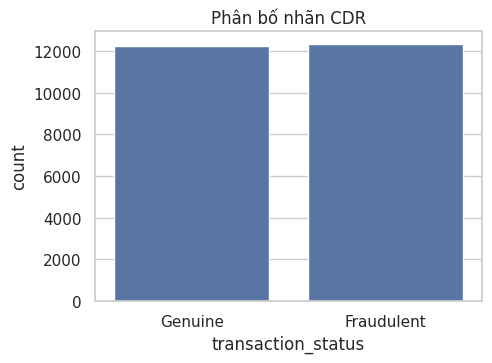

In [10]:
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df_raw, x=target_col)
plt.title("Phân bố nhãn CDR")
plt.show()

In [11]:
# EDA numeric chính
df_raw[["duration_sec", "is_night_call"]].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_sec,24543.0,163.143422,176.773624,10.0,38.0,103.0,226.0,1840.0
is_night_call,24543.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


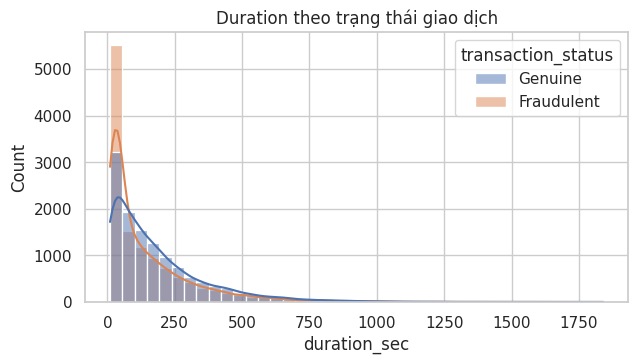

In [12]:
plt.figure(figsize=(7, 3.5))
sns.histplot(data=df_raw, x="duration_sec", hue=target_col, bins=40, kde=True)
plt.title("Duration theo trạng thái giao dịch")
plt.show()

In [13]:
pd.crosstab(df_raw["call_type"], df_raw[target_col], normalize="index")

transaction_status,Fraudulent,Genuine
call_type,,
international,0.610620,0.389380
local,0.433247,0.566753


# B2. Tiền xử lý dữ liệu

In [14]:
# Drop ID/leakage ngay từ đầu
drop_reason = pd.DataFrame([
    ("caller_id", "ID gần như duy nhất"),
    ("receiver_id", "ID gần như duy nhất"),
    ("sim_id", "ID/cardinality cao"),
    ("device_id", "ID/cardinality cao"),
    ("fraud_type", "Leakage: loại fraud chỉ biết sau điều tra"),
    ("transaction_status", "Target"),
], columns=["column", "reason"])

drop_reason

,column,reason
0,caller_id,ID gần như duy nhất
1,receiver_id,ID gần như duy nhất
2,sim_id,ID/cardinality cao
3,device_id,ID/cardinality cao
4,fraud_type,Leakage: loại fraud chỉ biết sau điều tra
5,transaction_status,Target


In [15]:
def add_cdr_features(df):
    out = df.copy()
    out["start_time"] = pd.to_datetime(out["start_time"], errors="coerce")
    out["call_hour"] = out["start_time"].dt.hour
    out["call_minute"] = out["start_time"].dt.minute
    out["call_dayofweek"] = out["start_time"].dt.dayofweek
    out["duration_log1p"] = np.log1p(out["duration_sec"])
    out["is_long_call"] = (out["duration_sec"] >= out["duration_sec"].median()).astype(int)
    out["is_international_route"] = (out["country_origin"].astype(str) != out["country_dest"].astype(str)).astype(int)
    out["same_location"] = (out["location_origin"].astype(str) == out["location_dest"].astype(str)).astype(int)
    out["route_pair"] = out["country_origin"].astype(str) + "_to_" + out["country_dest"].astype(str)
    return out

df = add_cdr_features(df_raw)
X = df.drop(columns=[c for c in drop_reason["column"] if c in df.columns] + ["start_time"])

constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if constant_cols:
    print("Drop feature hằng số:", constant_cols)
    X = X.drop(columns=constant_cols)

print("X shape:", X.shape)
X.head()

Drop feature hằng số: ['is_night_call', 'call_hour', 'call_dayofweek']
X shape: (24543, 12)


,duration_sec,call_type,location_origin,country_origin,location_dest,country_dest,call_minute,duration_log1p,is_long_call,is_international_route,same_location,route_pair
0,293,local,Kampala,UG,Johannesburg,ZA,9,5.683580,1,1,0,UG_to_ZA
1,213,international,Cairo,EG,Lagos,NG,9,5.365976,1,1,0,EG_to_NG
2,191,international,Lagos,NG,Lagos,NG,9,5.257495,1,0,1,NG_to_NG
3,14,international,Nairobi,KE,Addis Ababa,ET,9,2.708050,0,1,0,KE_to_ET
4,166,international,Cairo,EG,Addis Ababa,ET,9,5.117994,1,1,0,EG_to_ET


In [16]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

feature_audit = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
    "n_unique": [X[c].nunique(dropna=False) for c in numeric_features + categorical_features],
})
feature_audit

,feature,type,n_unique
0,duration_sec,numeric,958
1,call_minute,numeric,2
2,duration_log1p,numeric,958
3,is_long_call,numeric,2
4,is_international_route,numeric,2
5,same_location,numeric,2
6,call_type,categorical,2
7,location_origin,categorical,7
8,country_origin,categorical,7
9,location_dest,categorical,7


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "fraud_ratio": [y_train.mean(), y_test.mean()],
})

,split,rows,fraud_ratio
0,train,19634,0.501986
1,test,4909,0.501935


In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    verbose_feature_names_out=True,
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['duration_sec', 'call_minute',
                                  'duration_log1p', 'is_long_call',
                                  'is_international_route', 'same_location']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['call_type', 'location_origin',
                                  'country_origin', 'location_dest',
                                  'country_dest', 'route_pair'])])

# B3. Xây dựng mô hình và huấn luyện

In [19]:
def classification_metrics(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return {
        "model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1-score": f1_score(y_eval, pred, zero_division=0),
    }

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gaussian Naive Bayes": GaussianNB(),
    "SVM RBF": SVC(C=1.0, kernel="rbf", random_state=SEED),
}

fitted_models = {}
rows = []
for name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    rows.append(classification_metrics(name, pipe, X_test, y_test))

model_results_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False)
model_results_df

,model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.574659,0.576735,0.573458,0.575092
1,Gaussian Naive Bayes,0.519861,0.517983,0.625406,0.566648
2,SVM RBF,0.606845,0.719934,0.354708,0.475258


In [21]:
best_name = model_results_df.iloc[0]["model"]
best_model = fitted_models[best_name]

pd.DataFrame(
    confusion_matrix(y_test, best_model.predict(X_test)),
    index=["Actual Genuine", "Actual Fraudulent"],
    columns=["Pred Genuine", "Pred Fraudulent"],
)

,Pred Genuine,Pred Fraudulent
Actual Genuine,1408,1037
Actual Fraudulent,1051,1413


In [22]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_rows = []
for name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])
    cv_result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_accuracy": cv_result["test_accuracy"].mean(),
        "cv_precision": cv_result["test_precision"].mean(),
        "cv_recall": cv_result["test_recall"].mean(),
        "cv_f1": cv_result["test_f1"].mean(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("cv_f1", ascending=False)
cv_results_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1
1,Gaussian Naive Bayes,0.540643,0.536469,0.625202,0.577429
0,Logistic Regression,0.576194,0.578960,0.571226,0.575057
2,SVM RBF,0.603545,0.694984,0.374797,0.486938


# B4. Đánh giá và tối ưu mô hình

Dataset CDR trong lab này có phân bố nhãn gần cân bằng, nên phần B4 tập trung vào **feature selection**, **PCA** và **GridSearchCV**. Không dùng undersampling, oversampling hoặc SMOTE để tránh làm bài lab bị lệch khỏi bản chất dữ liệu.

In [23]:
# Feature selection bằng SelectKBest
selection_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("select", SelectKBest(score_func=f_classif, k=min(10, len(numeric_features) + 30))),
    ("model", LogisticRegression(max_iter=1000)),
])
selection_model.fit(X_train, y_train)
selection_metric = classification_metrics("SelectKBest + Logistic", selection_model, X_test, y_test)
selection_metric

{'model': 'SelectKBest + Logistic',
 'Accuracy': 0.5758810348339785,
 'Precision': 0.578665568369028,
 'Recall': 0.570211038961039,
 'F1-score': 0.5744071954210956}

In [24]:
# PCA pipeline
pca_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("pca", PCA(n_components=0.95, random_state=SEED)),
    ("model", LogisticRegression(max_iter=1000)),
])
pca_model.fit(X_train, y_train)
pca_metric = classification_metrics("PCA 95% + Logistic", pca_model, X_test, y_test)
pca_metric

{'model': 'PCA 95% + Logistic',
 'Accuracy': 0.575677327357914,
 'Precision': 0.5777233782129743,
 'Recall': 0.5746753246753247,
 'F1-score': 0.5761953204476093}

In [25]:
# Grid Search đơn giản cho Logistic Regression
grid_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

param_grid = {"model__C": [0.1, 1.0, 3.0], "model__solver": ["lbfgs"]}
search = GridSearchCV(grid_model, param_grid, scoring="f1", cv=cv, n_jobs=-1)
search.fit(X_train, y_train)

grid_metric = classification_metrics("GridSearch Logistic", search.best_estimator_, X_test, y_test)
grid_metric["best_params"] = str(search.best_params_)
grid_metric

{'model': 'GridSearch Logistic',
 'Accuracy': 0.5746587899775922,
 'Precision': 0.5765472312703583,
 'Recall': 0.5746753246753247,
 'F1-score': 0.5756097560975609,
 'best_params': "{'model__C': 0.1, 'model__solver': 'lbfgs'}"}

In [26]:
comparison_df = pd.concat([
    model_results_df,
    pd.DataFrame([selection_metric, pca_metric, grid_metric]),
], ignore_index=True).sort_values("F1-score", ascending=False)
comparison_df

,model,Accuracy,Precision,Recall,F1-score,best_params
4,PCA 95% + Logistic,0.575677,0.577723,0.574675,0.576195,NaN
5,GridSearch Logistic,0.574659,0.576547,0.574675,0.575610,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"
0,Logistic Regression,0.574659,0.576735,0.573458,0.575092,NaN
3,SelectKBest + Logistic,0.575881,0.578666,0.570211,0.574407,NaN
1,Gaussian Naive Bayes,0.519861,0.517983,0.625406,0.566648,NaN
2,SVM RBF,0.606845,0.719934,0.354708,0.475258,NaN


In [27]:
# Feature importance từ Logistic Regression đã tune
best_linear = search.best_estimator_
encoded_names = best_linear.named_steps["preprocess"].get_feature_names_out()
coefs = np.abs(best_linear.named_steps["model"].coef_[0])
encoded_importance = pd.DataFrame({"encoded_feature": encoded_names, "importance": coefs})

def to_original_feature(encoded_name):
    clean = encoded_name.split("__", 1)[1]
    for col in numeric_features + categorical_features:
        if clean == col or clean.startswith(col + "_"):
            return col
    return clean

encoded_importance["original_feature"] = encoded_importance["encoded_feature"].map(to_original_feature)
feature_importance = (
    encoded_importance.groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
top10_features = feature_importance.head(10)["original_feature"].tolist()
feature_importance.head(12)

,original_feature,importance
10,route_pair,3.511853
1,call_type,0.611000
4,duration_log1p,0.223856
3,country_origin,0.114857
9,location_origin,0.114857
7,is_long_call,0.100607
8,location_dest,0.085686
2,country_dest,0.085686
11,same_location,0.057869
6,is_international_route,0.057869


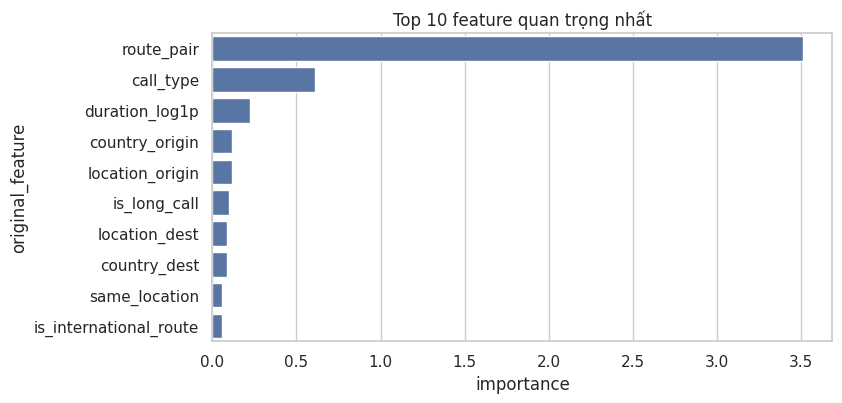

Top 10: ['route_pair', 'call_type', 'duration_log1p', 'country_origin', 'location_origin', 'is_long_call', 'location_dest', 'country_dest', 'same_location', 'is_international_route']


In [28]:
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance.head(10), x="importance", y="original_feature")
plt.title("Top 10 feature quan trọng nhất")
plt.show()
print("Top 10:", top10_features)

# B5. Triển khai trên web app

In [29]:
X_train_top = X_train[top10_features].copy()
X_test_top = X_test[top10_features].copy()
top_numeric = [c for c in top10_features if c in numeric_features]
top_categorical = [c for c in top10_features if c in categorical_features]

top_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, top_numeric),
        ("cat", categorical_transformer, top_categorical),
    ],
    verbose_feature_names_out=True,
)

app_model = Pipeline(steps=[
    ("preprocess", top_preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])
app_model.fit(X_train_top, y_train)
app_metrics = pd.DataFrame([classification_metrics("Top-10 Logistic app model", app_model, X_test_top, y_test)])
app_metrics

,model,Accuracy,Precision,Recall,F1-score
0,Top-10 Logistic app model,0.575474,0.576799,0.57914,0.577967


In [30]:
ARTIFACT_DIR = Path("artifacts/lab_3_2_cdr_fraud")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
bundle_path = ARTIFACT_DIR / "cdr_top10_fraud_model.joblib"

joblib.dump({
    "model": app_model,
    "top10_features": top10_features,
    "metrics": app_metrics,
    "feature_importance": feature_importance,
}, bundle_path)
print("Đã lưu:", bundle_path)

Đã lưu: artifacts/lab_3_2_cdr_fraud/cdr_top10_fraud_model.joblib


In [31]:
def make_default_value(col):
    if col in top_numeric:
        return float(X_train[col].median())
    values = sorted(X_train[col].dropna().astype(str).unique().tolist())
    return values[0]

def build_input_components():
    components = []
    for col in top10_features:
        if col in top_numeric:
            components.append(gr.Number(value=make_default_value(col), label=col))
        else:
            choices = sorted(X_train[col].dropna().astype(str).unique().tolist())
            components.append(gr.Dropdown(choices=choices, value=make_default_value(col), label=col))
    return components

def predict_cdr_fraud(*values):
    row = pd.DataFrame([dict(zip(top10_features, values))])
    for col in top_numeric:
        row[col] = pd.to_numeric(row[col], errors="coerce")
    proba = app_model.predict_proba(row[top10_features])[0]
    pred = int(np.argmax(proba))
    label = "Fraudulent" if pred == 1 else "Genuine"
    proba_table = pd.DataFrame({
        "label": ["Genuine", "Fraudulent"],
        "probability": [round(float(proba[0]), 4), round(float(proba[1]), 4)],
    })
    fig, ax = plt.subplots(figsize=(4.5, 3))
    sns.barplot(data=proba_table, x="label", y="probability", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title("Xác suất mỗi nhãn")
    fig.tight_layout()
    note = "Demo dùng model top-10 feature; không dùng ID hoặc fraud_type."
    return label, proba_table, fig, note

Prediction: Fraudulent


,label,probability
0,Genuine,0.4227
1,Fraudulent,0.5773


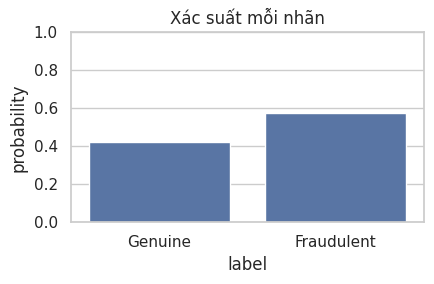

In [32]:
default_values = [make_default_value(col) for col in top10_features]
smoke_label, smoke_proba, _, smoke_note = predict_cdr_fraud(*default_values)
print("Prediction:", smoke_label)
smoke_proba

In [33]:
with gr.Blocks(title="CDR Fraud Detection") as cdr_demo:
    gr.Markdown("# CDR Fraud Detection")
    gr.Markdown("Nhập 10 feature quan trọng nhất để dự đoán bản ghi CDR là Genuine hay Fraudulent.")
    with gr.Row():
        with gr.Column():
            input_components = build_input_components()
            run_button = gr.Button("Dự đoán CDR", variant="primary")
        with gr.Column():
            prediction_output = gr.Textbox(label="Prediction")
            probability_output = gr.Dataframe(label="Xác suất mỗi nhãn")
            probability_plot = gr.Plot(label="Probability chart")
            note_output = gr.Markdown()
    metric_output = gr.Dataframe(value=app_metrics.round(4), label="Metric của app model trên test set")

    run_button.click(
        fn=predict_cdr_fraud,
        inputs=input_components,
        outputs=[prediction_output, probability_output, probability_plot, note_output],
    )
    cdr_demo.load(
        fn=predict_cdr_fraud,
        inputs=input_components,
        outputs=[prediction_output, probability_output, probability_plot, note_output],
    )

cdr_demo

Gradio Blocks instance: 2 backend functions
-------------------------------------------
fn_index=0
 inputs:
 |-<gradio.components.dropdown.Dropdown object at 0x7bed1e9c6db0>
 |-<gradio.components.dropdown.Dropdown object at 0x7bed1f5ab140>
 |-<gradio.components.number.Number object at 0x7bed1f935160>
 |-<gradio.components.dropdown.Dropdown object at 0x7bed1f9355b0>
 |-<gradio.components.dropdown.Dropdown object at 0x7bed1fbcc7a0>
 |-<gradio.components.number.Number object at 0x7bed1e9f87d0>
 |-<gradio.components.dropdown.Dropdown object at 0x7bed1f5a9580>
 |-<gradio.components.dropdown.Dropdown object at 0x7bed1f4bf020>
 |-<gradio.components.number.Number object at 0x7bed1f3017c0>
 |-<gradio.components.number.Number object at 0x7bed1f3009e0>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x7bed1ea03f50>
 |-<gradio.components.dataframe.Dataframe object at 0x7bed20d817f0>
 |-<gradio.components.plot.Plot object at 0x7bed1f52c5f0>
 |-<gradio.components.markdown.Markdown object a

In [34]:
try:
    launch_result = cdr_demo.launch(share=True, prevent_thread_lock=True)
    print("Gradio launch called with share=True.")
except Exception as exc:
    print("Không launch được Gradio trong môi trường hiện tại.")
    print(type(exc).__name__, str(exc)[:400])

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f05f825f5fb8af184b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio launch called with share=True.


## Kết luận ngắn

- CDR Fraud là bài toán phân loại nhị phân; target là `transaction_status`.
- `fraud_type` bị loại vì là thông tin hậu nghiệm.
- Dataset CDR trong lab này gần cân bằng lớp, nên không cần thêm undersampling, oversampling hoặc SMOTE.
- Bước tối ưu tập trung vào SelectKBest, PCA và GridSearchCV.
- App chỉ dùng 10 feature quan trọng nhất để giao diện nhập liệu gọn và dễ demo.